# Singapore HDB Resale Prices & Macroeconomic Conditions

**Question:** How is resident unemployment associated with quarterly average HDB resale prices, after accounting for Treasury bill yields and GDP growth?

An exploratory Python and SQL analysis of **32 quarters, 2017–2024**, using public Singapore government data. See [data sources](data/README.md).

The notebook runs offline using a compact [data snapshot](data/README.md). It studies associations, not causal effects or validated out-of-sample forecasts.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from src.prepare_data import validate_frame

ROOT = Path.cwd()
REPORTS = ROOT / 'reports'
REPORTS.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
df = validate_frame(pd.read_csv(ROOT / 'data/quarterly_2017_2024.csv'))
display(df.head())
print(f'{len(df)} complete quarters; {df.year_quarter.iloc[0]} to {df.year_quarter.iloc[-1]}')

,year_quarter,avg_resale_price,unemployment_rate,avg_tbill_yield,gdp_growth
0,2017-Q1,440669.853314,3.0,1.023333,4.6
1,2017-Q2,443563.626418,4.2,1.050000,3.6
2,2017-Q3,445364.309594,2.7,1.193333,5.2
3,2017-Q4,445241.993996,2.5,1.483333,4.4
4,2018-Q1,450316.963491,2.7,1.566667,4.6


32 complete quarters; 2017-Q1 to 2024-Q4


## Data preparation

The raw-data pipeline aggregates HDB transactions to quarterly mean prices, reshapes resident unemployment and GDP from wide to long format, averages monthly Treasury bill yields, then joins four tables in SQLite on `year_quarter`.

Run `python src/prepare_data.py` after placing the four source exports in `data/raw/` to rebuild. This notebook uses the included integrated dataset, rounded to six decimal places; it does not need a drive mount or private file path.

,avg_resale_price,unemployment_rate,avg_tbill_yield,gdp_growth
count,32.000,32.000,32.000,32.000
mean,501455.761,3.134,1.898,3.216
std,67458.106,0.738,1.232,4.563
min,429740.702,2.300,0.300,-11.900
25%,440627.781,2.600,0.970,1.475
50%,484202.371,2.800,1.760,3.300
75%,558767.871,3.525,3.042,4.625
max,634543.668,5.200,3.917,18.300


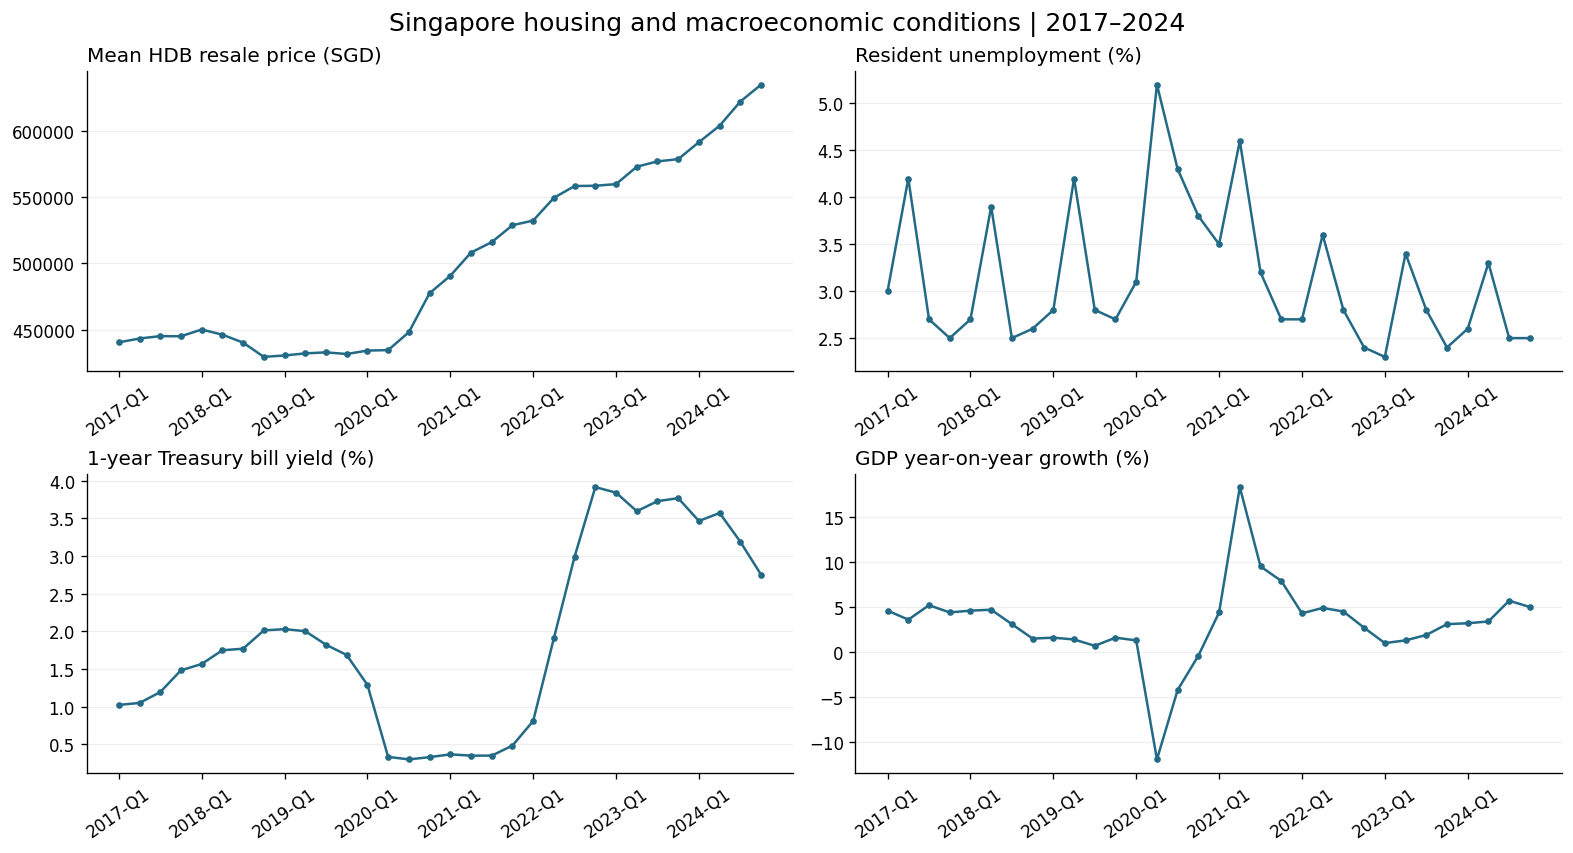

In [2]:
display(df.describe().round(3))
fig, axes = plt.subplots(2, 2, figsize=(13, 7), constrained_layout=True)
labels = [('avg_resale_price', 'Mean HDB resale price (SGD)'), ('unemployment_rate', 'Resident unemployment (%)'), ('avg_tbill_yield', '1-year Treasury bill yield (%)'), ('gdp_growth', 'GDP year-on-year growth (%)')]
for ax, (column, label) in zip(axes.flat, labels):
    ax.plot(df.year_quarter, df[column], marker='o', markersize=3, color='#236a86')
    ax.set_title(label, loc='left')
    ax.set_xticks(range(0, 32, 4), df.year_quarter.iloc[::4], rotation=35)
    ax.grid(axis='y', alpha=.2)
fig.suptitle('Singapore housing and macroeconomic conditions | 2017–2024', fontsize=15)
fig.savefig(REPORTS / 'overview.png', bbox_inches='tight')
plt.show()

## Correlation and seasonal sensitivity

Compare raw unemployment with a simple adjustment that subtracts each calendar quarter's mean and adds the overall mean. This is an exploratory within-sample adjustment, not an official seasonally adjusted series. A Q2 pattern alone does not identify its cause. Conventional Pearson p-values assume independent observations, which may fail for these trending time series.

In [3]:
df['quarter_num'] = df.year_quarter.str[-1].astype(int)
seasonal_means = df.groupby('quarter_num').unemployment_rate.mean()
df['unemployment_adjusted'] = df.unemployment_rate - df.quarter_num.map(seasonal_means) + df.unemployment_rate.mean()
correlations = []
for column in ['unemployment_rate', 'unemployment_adjusted', 'avg_tbill_yield', 'gdp_growth']:
    result = stats.pearsonr(df[column], df.avg_resale_price)
    correlations.append({'variable': column, 'r': result.statistic, 'p_value': result.pvalue})
correlations = pd.DataFrame(correlations)
display(correlations.round(4))
periods = {'2017–2019': df.iloc[:12], '2020–2021': df.iloc[12:20], '2022–2024': df.iloc[20:]}
regimes = []
for period, subset in periods.items():
    result = stats.pearsonr(subset.unemployment_rate, subset.avg_resale_price)
    regimes.append({'period': period, 'n': len(subset), 'r': result.statistic, 'p_value': result.pvalue})
display(pd.DataFrame(regimes).round(4))

,variable,r,p_value
0,unemployment_rate,-0.3281,0.0667
1,unemployment_adjusted,-0.4558,0.0088
2,avg_tbill_yield,0.6396,0.0001
3,gdp_growth,0.2598,0.1510


,period,n,r,p_value
0,2017–2019,12,0.0698,0.8294
1,2020–2021,8,-0.4680,0.2422
2,2022–2024,12,-0.1719,0.5931


## Multiple linear regression

Fit price on resident unemployment, Treasury bill yield, and GDP growth. Least squares uses `numpy.linalg.lstsq`; standard errors and two-sided t-tests use the conventional homoskedastic OLS covariance. These are in-sample estimates, not forecasting performance. Shared time trends, autocorrelation, omitted policies, and the changing mix of transacted flats can confound them.

In [4]:
features = ['unemployment_rate', 'avg_tbill_yield', 'gdp_growth']
X = np.column_stack([np.ones(len(df)), df[features].to_numpy()])
y = df.avg_resale_price.to_numpy()
beta, _, rank, _ = np.linalg.lstsq(X, y, rcond=None)
assert rank == X.shape[1]
fitted = X @ beta
residuals = y - fitted
n, k = X.shape
mse = residuals @ residuals / (n - k)
se = np.sqrt(np.diag(mse * np.linalg.inv(X.T @ X)))
p_values = 2 * stats.t.sf(np.abs(beta / se), df=n-k)
r_squared = 1 - (residuals @ residuals) / np.sum((y-y.mean())**2)
adj_r_squared = 1 - (1-r_squared) * (n-1) / (n-k)
regression = pd.DataFrame({'variable': ['intercept'] + features, 'coefficient': beta, 'standard_error': se, 'p_value': p_values})
display(regression.round(4))
print(f'In-sample R² = {r_squared:.4f}; adjusted R² = {adj_r_squared:.4f}')

,variable,coefficient,standard_error,p_value
0,intercept,377654.2910,60322.9585,0.0000
1,unemployment_rate,10755.8924,14883.1448,0.4759
2,avg_tbill_yield,39377.9466,8741.2590,0.0001
3,gdp_growth,4767.9383,2048.1537,0.0274


In-sample R² = 0.5050; adjusted R² = 0.4520


The reproduced model has **R² ≈ 0.505**. The unemployment coefficient is positive and statistically non-significant (**p ≈ 0.476**), so this specification does not support the proposed negative association after controls. Treasury bill yield and GDP growth have positive coefficients with conventional p-values below 0.05. These estimates do not establish economic drivers.

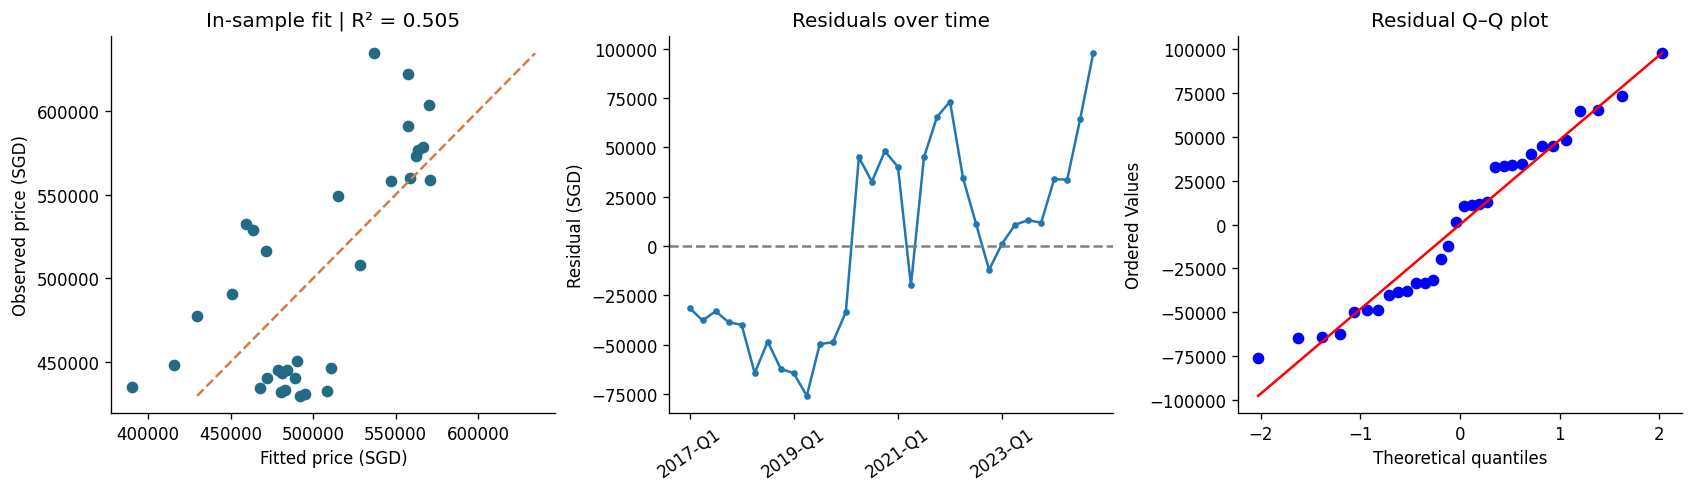

VIF: {'unemployment_rate': np.float64(1.5), 'avg_tbill_yield': np.float64(1.441), 'gdp_growth': np.float64(1.086)}
Durbin–Watson descriptive statistic: 0.322


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
axes[0].scatter(fitted, y, color='#236a86')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], '--', color='#d77b45')
axes[0].set(xlabel='Fitted price (SGD)', ylabel='Observed price (SGD)', title=f'In-sample fit | R² = {r_squared:.3f}')
axes[1].plot(df.year_quarter, residuals, marker='o', markersize=3)
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_xticks(range(0, 32, 8), df.year_quarter.iloc[::8], rotation=35)
axes[1].set(title='Residuals over time', ylabel='Residual (SGD)')
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Residual Q–Q plot')
fig.savefig(REPORTS / 'diagnostics.png', bbox_inches='tight')
plt.show()
vifs = {}
for j, feature in enumerate(features, start=1):
    others = np.delete(X, j, axis=1)
    auxiliary = others @ np.linalg.lstsq(others, X[:, j], rcond=None)[0]
    r2 = 1 - np.sum((X[:, j]-auxiliary)**2) / np.sum((X[:, j]-X[:, j].mean())**2)
    vifs[feature] = 1 / (1-r2)
print('VIF:', {key: round(value, 3) for key, value in vifs.items()})
print('Durbin–Watson descriptive statistic:', round(np.sum(np.diff(residuals)**2) / np.sum(residuals**2), 3))

## Group comparison

Split quarters at the median unemployment rate and compare their price distributions with a two-sided Mann–Whitney U test. This small, time-ordered sample does not meet a strong independence assumption; the test is descriptive and does not isolate unemployment from other changes over time.

In [6]:
median = df.unemployment_rate.median()
high = df.loc[df.unemployment_rate >= median, 'avg_resale_price']
low = df.loc[df.unemployment_rate < median, 'avg_resale_price']
u_test = stats.mannwhitneyu(high, low, alternative='two-sided')
print(f'High group: {len(high)} quarters; low group: {len(low)} quarters')
print(f'U = {u_test.statistic:.1f}; p = {u_test.pvalue:.6f}')
results = {'n_quarters': len(df), 'r_squared': r_squared, 'adjusted_r_squared': adj_r_squared,
           'correlations': correlations.to_dict(orient='records'), 'regression': regression.to_dict(orient='records'),
           'regime_correlations': regimes, 'vif': vifs,
           'mann_whitney': {'u': float(u_test.statistic), 'p_value': float(u_test.pvalue)}}
(REPORTS / 'results.json').write_text(json.dumps(results, indent=2) + '\n')

High group: 18 quarters; low group: 14 quarters
U = 97.0; p = 0.278975


1944

## Findings and limitations

- Raw unemployment and prices have a negative correlation (r ≈ −0.328, p ≈ 0.067). The simple seasonal adjustment strengthens it (r ≈ −0.456, p ≈ 0.009), but time-series assumptions and the adjustment's estimation uncertainty limit inference.
- None of the three short-period correlations is conventionally significant; their small samples limit statistical power.
- Unemployment is not significant in the multiple regression. The model's R² describes fit on the same 32 observations used for estimation.
- The Mann–Whitney comparison is **not significant** (U = 97, p ≈ 0.279).
- Aggregate transaction prices are affected by flat type, location, size, lease, and the mix of sales. Treasury bill yield is a broad rate proxy, not a measured mortgage rate.

**Next steps:** use mix-adjusted prices, test stationarity and first differences, add time trends and lagged variables, estimate autocorrelation-robust uncertainty, and evaluate any prediction model with time-ordered holdouts. This exploratory analysis does not justify a housing-policy recommendation.